In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load in merged dataset from 2021-2023
df = pd.read_csv("../data/cleaned/nyts_2021_2023_clean.csv")
np.random.seed(42)
print("Dataset shape:", df.shape)
print("\nClass balance:")
print(df["ecig_current"].value_counts(normalize=True))


Dataset shape: (12588, 26)

Class balance:
ecig_current
0    0.547029
1    0.452971
Name: proportion, dtype: float64


In [3]:
# define features and target variable
feature_names = df.drop(columns=["usage", "ecig_current", "year"]).columns.tolist() # in case needed later
X = df.drop(columns=["usage", "ecig_current", "year"]).values
y = df["ecig_current"].values.reshape(-1, 1)

print("\nFeature matrix shape:", X.shape)
print("Target vector shape:", y.shape)


Feature matrix shape: (12588, 23)
Target vector shape: (12588, 1)


In [4]:
# manual train test split 80/ 20
np.random.seed(42)

n = X.shape[0]
indices = np.random.permutation(n)

test_size = int(0.2 * n)
test_idx = indices[:test_size]
train_idx = indices[test_size:]

X_train = X[train_idx]
X_test = X[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

# standardize the data
train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0)

# avoid dividing by 0
train_std[train_std == 0] = 1

X_train = (X_train - train_mean) / train_std
X_test = (X_test - train_mean) / train_std


In [5]:
# create an mlp helper functions
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def binary_cross_entropy(y_true, y_pred):
    eps = 1e-8
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

In [6]:
# build out mlp
np.random.seed(42)

input_dim = X_train.shape[1]
hidden1_dim = 32
hidden2_dim = 16
output_dim = 1

#W1 = np.random.randn(input_dim, hidden1_dim) * 0.01
W1 = np.random.randn(input_dim, hidden1_dim) * np.sqrt(2 / input_dim)
b1 = np.zeros((1, hidden1_dim))

#W2 = np.random.randn(hidden1_dim, hidden2_dim) * 0.01
W2 = np.random.randn(hidden1_dim, hidden2_dim) * np.sqrt(2 / hidden1_dim)
b2 = np.zeros((1, hidden2_dim))

#W3 = np.random.randn(hidden2_dim, output_dim) * 0.01
W3 = np.random.randn(hidden2_dim, output_dim) * np.sqrt(2 / hidden2_dim)
b3 = np.zeros((1, output_dim))

In [7]:
learning_rate = 0.001 # how big ea/ weight update is
epochs = 600 #  num full passes through training data
batch_size = 64 # num samples processed at a time
n_train = X_train.shape[0] # num training observations

loss_history = []

# training loop
for epoch in range(epochs):

    # shuffled to avoid learning order bias
    indices = np.random.permutation(n_train)
    X_train_shuffled = X_train[indices]
    y_train_shuffled = y_train[indices]

    epoch_loss = 0

    # iterate through data in small batches
    for start in range(0, n_train, batch_size):
        end = start + batch_size
        X_batch = X_train_shuffled[start:end]
        y_batch = y_train_shuffled[start:end]

        # forward pass
        # 1st hidde layer w relu activation
        Z1 = X_batch @ W1 + b1
        A1 = relu(Z1)

        # 2nd hidden layer w relu activation
        Z2 = A1 @ W2 + b2
        A2 = relu(Z2)

        # Output layer
        Z3 = A2 @ W3 + b3
        A3 = sigmoid(Z3)

        # calc binary cross entropy loss
        loss = binary_cross_entropy(y_batch, A3)
        epoch_loss += loss * len(X_batch)

        # backprop
        m = len(X_batch)

        # gradient loss w.r.t. output layer
        dZ3 = A3 - y_batch
        dW3 = (A2.T @ dZ3) / m
        db3 = np.sum(dZ3, axis=0, keepdims=True) / m

        # propagate error back to 2nd hidden layer
        dA2 = dZ3 @ W3.T
        dZ2 = dA2 * relu_derivative(Z2)
        dW2 = (A1.T @ dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        # propagate back to 1st hidden layer
        dA1 = dZ2 @ W2.T
        dZ1 = dA1 * relu_derivative(Z1)
        dW1 = (X_batch.T @ dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        # gradient descent update
        W3 -= learning_rate * dW3
        b3 -= learning_rate * db3

        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2

        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1

    # avg loss across whole epoch
    epoch_loss /= n_train
    loss_history.append(epoch_loss)

    if epoch % 50 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch}: loss = {epoch_loss:.4f}")

Epoch 0: loss = 0.7883
Epoch 50: loss = 0.6581
Epoch 100: loss = 0.6502
Epoch 150: loss = 0.6461
Epoch 200: loss = 0.6433
Epoch 250: loss = 0.6412
Epoch 300: loss = 0.6394
Epoch 350: loss = 0.6379
Epoch 400: loss = 0.6366
Epoch 450: loss = 0.6353
Epoch 500: loss = 0.6341
Epoch 550: loss = 0.6330
Epoch 599: loss = 0.6321



--- Threshold = 0.5 ---
Accuracy:  0.6333
Precision: 0.6130
Recall:    0.5279
F1:        0.5673
Confusion Matrix:
[[989 382]
 [541 605]]

--- Threshold = 0.3 ---
Accuracy:  0.5431
Precision: 0.4990
Recall:    0.8778
F1:        0.6363
Confusion Matrix:
[[ 361 1010]
 [ 140 1006]]


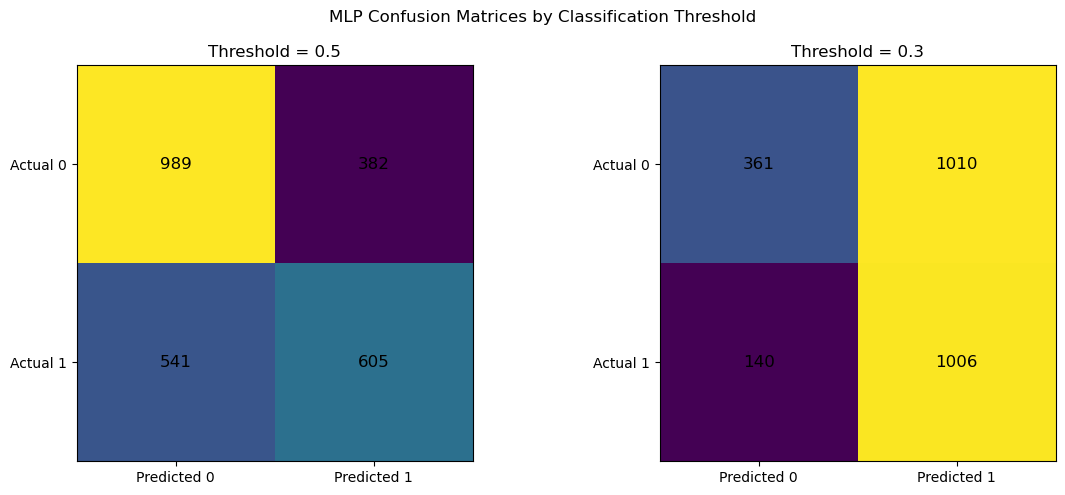

In [17]:
# make some predictions with the different activation functions
Z1_test = X_test @ W1 + b1
A1_test = relu(Z1_test)

Z2_test = A1_test @ W2 + b2
A2_test = relu(Z2_test)

Z3_test = A2_test @ W3 + b3
y_prob = sigmoid(Z3_test)

# evaluating diff thresholds
for thresh in [0.5, 0.3]:
    y_pred_t = (y_prob >= thresh).astype(int)

    accuracy  = np.mean(y_pred_t == y_test)
    tp = np.sum((y_test == 1) & (y_pred_t == 1))
    tn = np.sum((y_test == 0) & (y_pred_t == 0))
    fp = np.sum((y_test == 0) & (y_pred_t == 1))
    fn = np.sum((y_test == 1) & (y_pred_t == 0))
    precision = tp / (tp + fp + 1e-8)
    recall    = tp / (tp + fn + 1e-8)
    f1        = 2 * precision * recall / (precision + recall + 1e-8)

    print(f"\n--- Threshold = {thresh} ---")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1:        {f1:.4f}")
    print(f"Confusion Matrix:\n{np.array([[tn, fp],[fn, tp]])}")

# plot confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, thresh in zip(axes, [0.5, 0.3]):
    y_pred_t = (y_prob >= thresh).astype(int)
    tp = np.sum((y_test == 1) & (y_pred_t == 1))
    tn = np.sum((y_test == 0) & (y_pred_t == 0))
    fp = np.sum((y_test == 0) & (y_pred_t == 1))
    fn = np.sum((y_test == 1) & (y_pred_t == 0))
    cm = np.array([[tn, fp], [fn, tp]])

    ax.imshow(cm)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Predicted 0", "Predicted 1"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Actual 0", "Actual 1"])
    ax.set_title(f"Threshold = {thresh}")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=12)

plt.suptitle("MLP Confusion Matrices by Classification Threshold")
plt.tight_layout()
plt.show()

In [15]:
# look at various metrics including accuracy, confusion matrix, precision, recall, F1, etc. yk the vibes

# accuracy
accuracy = np.mean(y_pred == y_test)
print("Accuracy:", accuracy)

# confusion matrix
tp = np.sum((y_test == 1) & (y_pred == 1))
tn = np.sum((y_test == 0) & (y_pred == 0))
fp = np.sum((y_test == 0) & (y_pred == 1))
fn = np.sum((y_test == 1) & (y_pred == 0))
print("Confusion Matrix:")
print(np.array([[tn, fp],
                [fn, tp]]))

# precision, recall, f1
precision = tp / (tp + fp + 1e-8)
recall = tp / (tp + fn + 1e-8)
f1 = 2 * precision * recall / (precision + recall + 1e-8)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.5431068732618196
Confusion Matrix:
[[ 361 1010]
 [ 140 1006]]
Precision: 0.49900793650546127
Recall: 0.8778359511267205
F1 Score: 0.6363061307318606


- Precision: Among students the model predicted as vapers, about 62% actually vape.
- Recall: Among all students who actually vape, the model only identifies 53% of them (misses about half of the real vaping cases)
- F1 score: 0.57 means the model has moderate predictive ability


- TN 989, TP: 605, FP: 382, FN: 541, 
- Students who do not vape and the model correctly predicted no was 989 (not horrible)
- Students who actually vape but the model predicted they don't (FN) 541 (not great)

Text(0, 0.5, 'Loss')

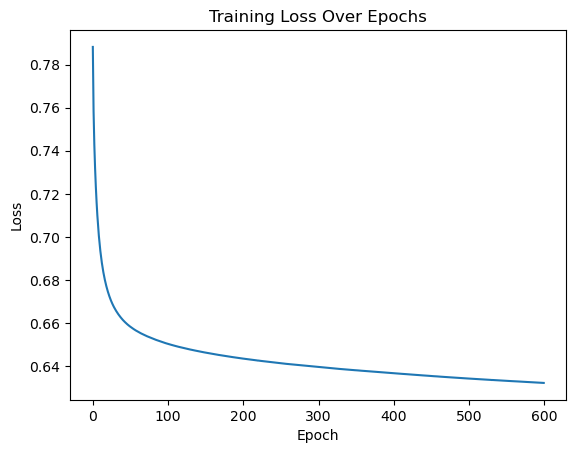

In [18]:
# plot mlp loss history
plt.plot(loss_history)
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss") # model converges steadily, indicating stable gradient-based learnin

In [19]:
# testing lower thresholds
for thresh in [0.3, 0.4, 0.5]:
    y_pred_t = (y_prob >= thresh).astype(int)
    tp = np.sum((y_test == 1) & (y_pred_t == 1))
    fp = np.sum((y_test == 0) & (y_pred_t == 1))
    fn = np.sum((y_test == 1) & (y_pred_t == 0))
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    print(f"Threshold {thresh}: Precision={precision:.3f}, Recall={recall:.3f}, F1={f1:.3f}")

Threshold 0.3: Precision=0.499, Recall=0.878, F1=0.636
Threshold 0.4: Precision=0.552, Recall=0.709, F1=0.621
Threshold 0.5: Precision=0.613, Recall=0.528, F1=0.567
